# Toy 1D Regression: SVD Optimizer Analysis

Analysis of SVD optimizer vs standard optimizers on 1D regression task.

## 1. Setup & Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/cifar10_ce')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /n/home11/sambt/iaifi/sv3/analysis/plots/cifar10_ce


In [2]:
# Load JSONL results
from style import load_results, load_results_jsonl

#df = load_results_jsonl("toy_1d_scan")
df = load_results("cifar10_resnet_ce_test")
print(f"Total: {len(df)} experiment runs")
print(f"Optimizers: {sorted(df['optimizer'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")
print(f"Columns: {df.columns.tolist()}")

Loaded 2 runs from ../experiment_results/cifar10_resnet_ce_test/ (directory format)
Total: 2 experiment runs
Optimizers: ['Adam', 'SVD']
Batch sizes: [64]
Columns: ['run_id', 'optimizer', 'batch_size', 'k_fraction', 'k', 'lr', 'rtol', 'weight_decay', 'model_seed', 'loader_seed', 'svd_mode', 'svd_info', 'losses', 'rmsProp', 'alpha_rmsProp', 'microbatch_size', 'param_fraction', 'variable_k']


### quick check

In [3]:
df_adam = df[df['optimizer'] == 'Adam']
df_sven = df[df['optimizer'] == 'SVD']

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

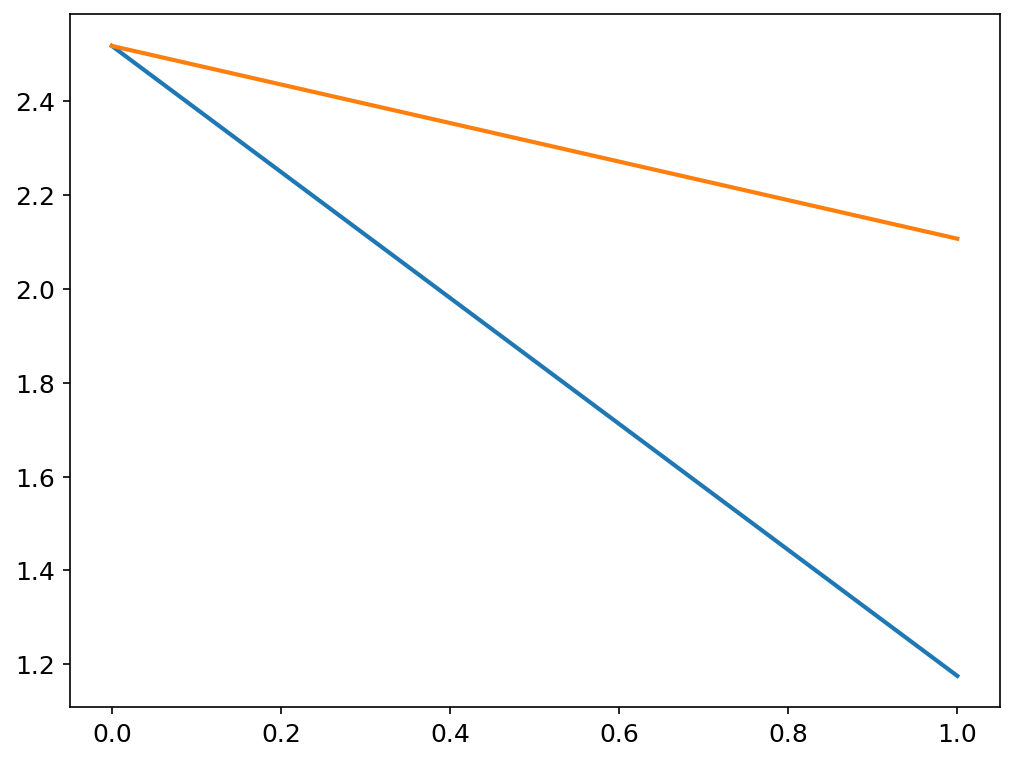

In [15]:
plt.figure(figsize=(8,6))
plt.plot(df_adam['losses'].iloc[0]['val'])
plt.plot(df_sven['losses'].iloc[0]['val'])

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

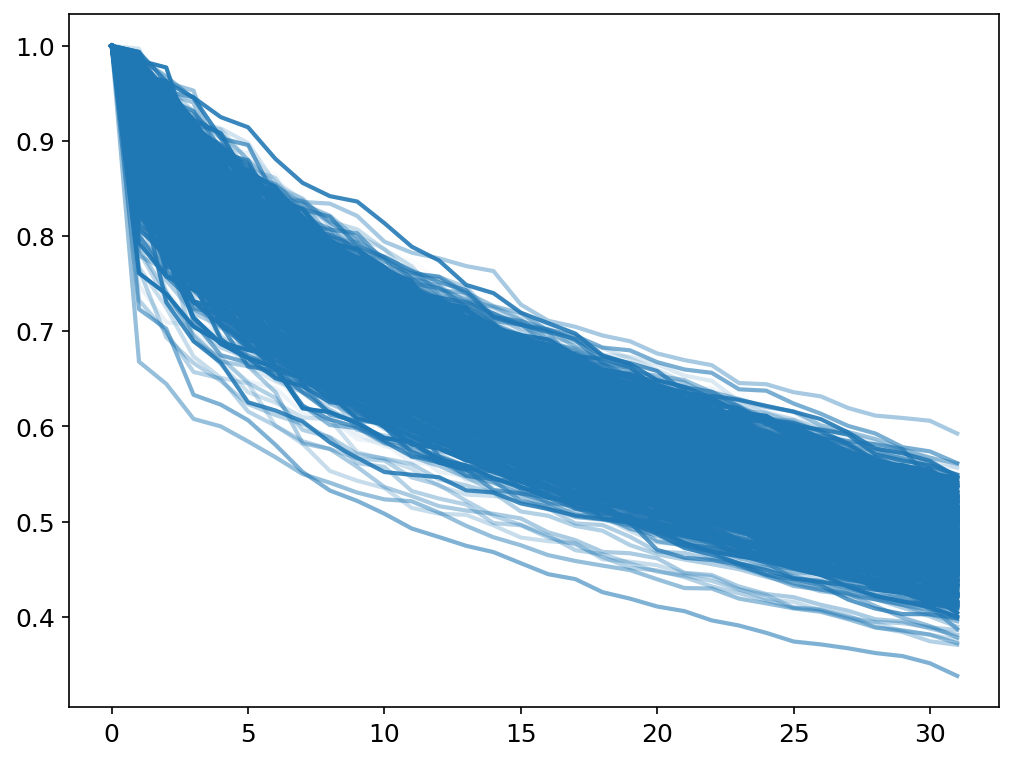

In [21]:
svd_info = df_sven['svd_info'].iloc[0]

plt.figure(figsize=(8,6))
N = len(svd_info['svs'])
for i,svs in enumerate(svd_info['svs']):
    s = np.array(svs)
    plt.plot(s/s[0],lw=2,alpha=(N-i)/N,color='C0')
